<a href="https://colab.research.google.com/github/myconcordia/INSE6220/blob/main/demo_boxplot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

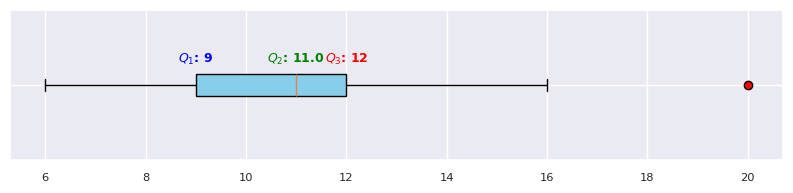

In [48]:
import seaborn as sns; sns.set()
sns.set(font_scale=.75)
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Styling
plt.rcParams['figure.figsize'] = (8,2)
rcParams.update({'figure.autolayout': True})

def plot_boxplot(data, label='Dataset'):
    # 1. Sort data and calculate custom quartiles (Median of Halves)
    sorted_data = sorted(data)
    n = len(sorted_data)

    # Q2 (Median)
    if n % 2 == 1:
        q2 = float(sorted_data[n // 2])
        low_h, upp_h = sorted_data[:n // 2], sorted_data[n // 2 + 1:]
    else:
        q2 = (sorted_data[n // 2 - 1] + sorted_data[n // 2]) / 2.0
        low_h, upp_h = sorted_data[:n // 2], sorted_data[n // 2:]

    # Q1 and Q3 (Medians of halves)
    q1 = (low_h[len(low_h)//2-1] + low_h[len(low_h)//2])/2.0 if len(low_h)%2==0 else low_h[len(low_h)//2]
    q3 = (upp_h[len(upp_h)//2-1] + upp_h[len(upp_h)//2])/2.0 if len(upp_h)%2==0 else upp_h[len(upp_h)//2]

    # 2. Outlier Logic
    iqr = q3 - q1
    lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    outliers = [x for x in data if x < lower_fence or x > upper_fence]
    non_outliers = [x for x in data if lower_fence <= x <= upper_fence]

    # 3. Create Boxplot Stats
    stats = [{
        "label": "",
        "q1": q1, "med": q2, "q3": q3,
        "whislo": min(non_outliers),
        "whishi": max(non_outliers),
        "fliers": outliers
    }]

    # 4. Plot
    fig, ax = plt.subplots()
    ax.bxp(stats, vert=False, patch_artist=True,
           boxprops=dict(facecolor='skyblue'),
           flierprops=dict(marker='o', markerfacecolor='red', markersize=6))

    # Annotations
    plt.text(q1, 1.15, f'$Q_1$: {q1}', ha='center', fontweight='bold', color='blue')
    plt.text(q2, 1.15, f'$Q_2$: {q2}', ha='center', fontweight='bold', color='green')
    plt.text(q3, 1.15, f'$Q_3$: {q3}', ha='center', fontweight='bold', color='red')

    plt.show()

# Data
X = [10, 10, 6, 12, 6, 9, 16, 20, 11, 10, 11, 11, 9, 12, 11]
#X = [5, 7, 4, 4, 6, 2, 8]
#X = [8, 6, 3, 1, 4, 3, 7, 8, 6, 5]
#X = [4, 17, 7, 14, 18, 12, 3, 16, 10, 4, 4, 11]
#X = [63, 64, 64, 70, 72, 76, 77, 81, 81]
#X = [99, 85, 86, 71, 82, 95, 108, 87, 89, 89, 78, 86]
#X = [23, 4, 29, 44, 47, 24, 40, 23, 23, 44, 33, 27, 60, 46, 61, 11, 23, 62, 31, 44, 77, 14, 65, 42]
plot_boxplot(X)